<a href="https://colab.research.google.com/github/202204417/25-2-DIP-202204417/blob/main/HW_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-500758386.py:135: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/tmp/ipython-input-500758386.py:135: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


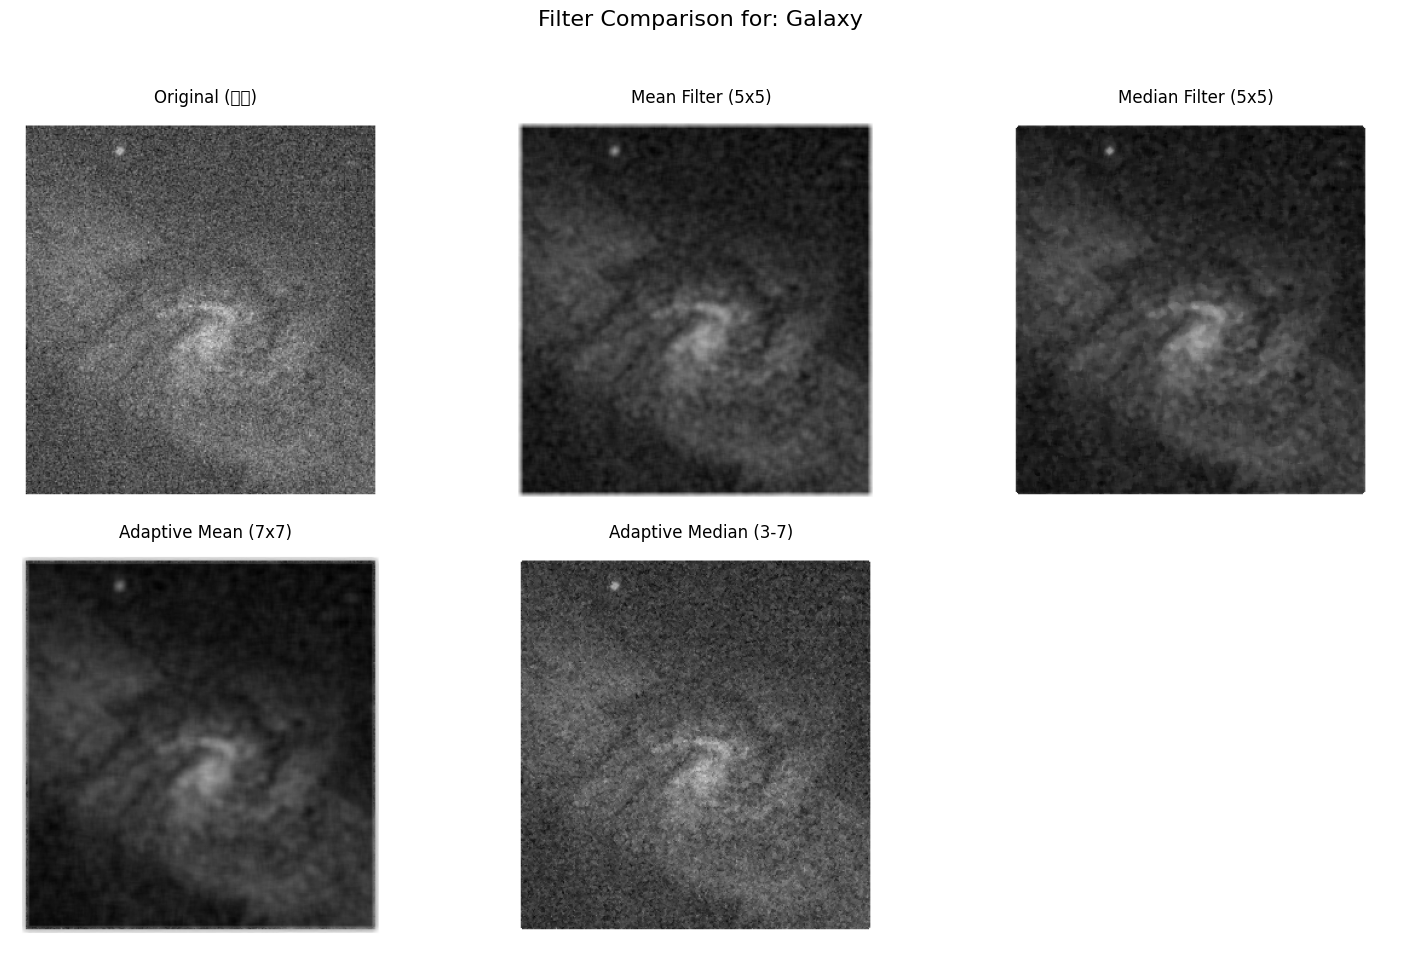

'Galaxy' 이미지에 대한 필터링 결과를 표시했습니다.


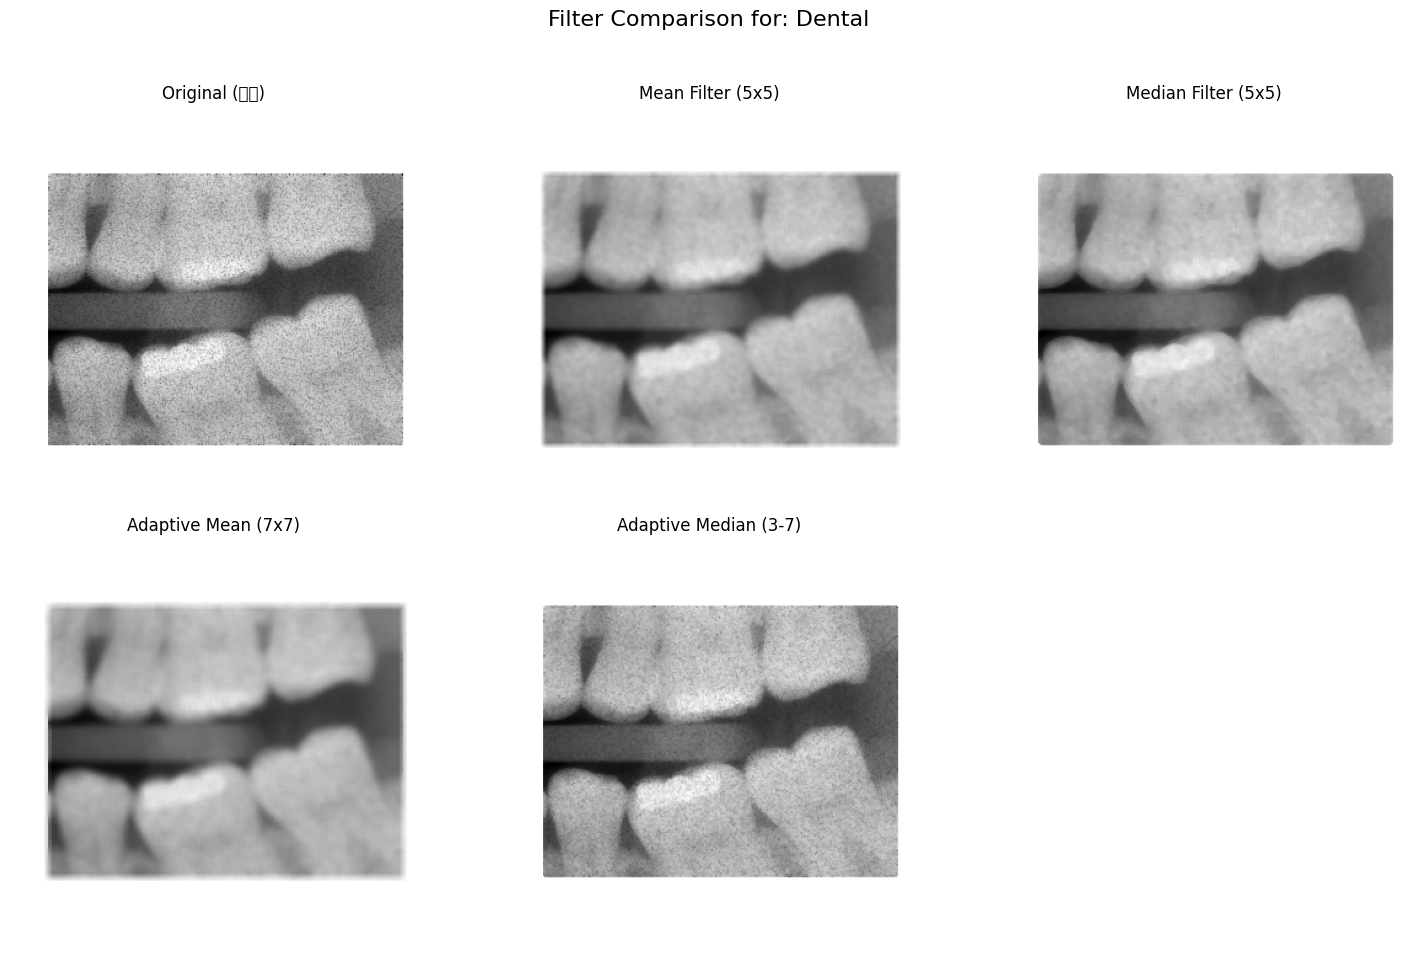

'Dental' 이미지에 대한 필터링 결과를 표시했습니다.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 1. 적응형 잡음 감소 필터 (Adaptive Mean) 구현
# -------------------------------------------------------------------
def adaptive_mean_filter(image, kernel_size=7):
    """Adaptive Local Noise Reduction Filter"""
    # 전역 노이즈 분산 추정 (이미지 전체 분산 사용)
    global_noise_var = np.var(image)

    pad_width = kernel_size // 2
    img_padded = np.pad(image.astype(float), pad_width, mode='reflect')
    output = np.zeros_like(image, dtype=float)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            # 국소 영역 추출
            local_region = img_padded[y:y+kernel_size, x:x+kernel_size]

            # 국소 통계치 계산
            local_mean = np.mean(local_region)
            local_var = np.var(local_region)

            g_xy = img_padded[y+pad_width, x+pad_width] # 원본 픽셀

            # 비율 계산 (0 나누기 방지 및 1.0으로 제한)
            ratio = global_noise_var / local_var if local_var != 0 else 1.0
            ratio = min(ratio, 1.0)

            # 필터 공식 적용
            output[y, x] = g_xy - ratio * (g_xy - local_mean)

    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

# -------------------------------------------------------------------
# 2. 적응형 미디언 필터 (Adaptive Median) 구현
# -------------------------------------------------------------------
def adaptive_median_filter(image, s_min=3, s_max=7):
    """Adaptive Median Filter"""
    if s_min % 2 == 0 or s_max % 2 == 0 or s_min > s_max:
        raise ValueError("s_min와 s_max는 홀수여야 하며, s_min <= s_max 여야 합니다.")

    pad_width = s_max // 2
    img_padded = np.pad(image.astype(float), pad_width, mode='reflect')
    output = np.zeros_like(image, dtype=float)

    g_xy = img_padded[pad_width:-pad_width, pad_width:-pad_width]

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            s = s_min
            while s <= s_max:
                half_s = s // 2
                # 국소 영역 S_xy 추출
                local_region = img_padded[y+pad_width-half_s : y+pad_width+half_s+1,
                                          x+pad_width-half_s : x+pad_width+half_s+1]

                z_min = np.min(local_region)
                z_max = np.max(local_region)
                z_med = np.median(local_region)

                # Level A
                A1 = z_med - z_min
                A2 = z_med - z_max

                if A1 > 0 and A2 < 0: # z_med가 노이즈가 아님
                    # Level B
                    B1 = g_xy[y, x] - z_min
                    B2 = g_xy[y, x] - z_max

                    if B1 > 0 and B2 < 0: # g(x,y)가 노이즈가 아님
                        output[y, x] = g_xy[y, x] # 원본값 사용
                    else: # g(x,y)가 노이즈임
                        output[y, x] = z_med # 미디언값 사용
                    break # while 루프 탈출
                else: # z_med가 노이즈임
                    s += 2 # 윈도우 크기 증가
                    if s > s_max: # 최대 크기 도달
                        output[y, x] = z_med # 현재 미디언값 사용
                        break

    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

# -------------------------------------------------------------------
# 3. 이미지 처리 및 결과 플롯 함수 (plt.show() 사용)
# -------------------------------------------------------------------
def show_filter_comparison(image_path, title_prefix):

    # 1. 이미지 로드 (그레이스케일)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: 이미지를 로드할 수 없습니다 {image_path}")
        return

    # --- 2. 필터 적용 ---

    # 2-1. Mean Filter (5x5 커널)
    mean_filtered = cv2.blur(img, (5, 5))

    # 2-2. Median Filter (5x5 커널)
    median_filtered = cv2.medianBlur(img, 5)

    # 2-3. Adaptive Noise Reduction (Mean) Filter (7x7 커널)
    adaptive_mean = adaptive_mean_filter(img, kernel_size=7)

    # 2-4. Adaptive Median Filter (최소 3x3, 최대 7x7)
    adaptive_median = adaptive_median_filter(img, s_min=3, s_max=7)

    # --- 3. 결과 시각화 (Matplotlib) ---
    titles = ['Original (원본)',
              'Mean Filter (5x5)',
              'Median Filter (5x5)',
              'Adaptive Mean (7x7)',
              'Adaptive Median (3-7)']

    images = [img, mean_filtered, median_filtered, adaptive_mean, adaptive_median]

    plt.figure(figsize=(15, 10))
    plt.suptitle(f'Filter Comparison for: {title_prefix}', fontsize=16)

    for i in range(5):
        plt.subplot(2, 3, i + 1) # 2행 3열 그리드
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # 4. 파일 저장이 아닌, 노트북에 바로 표시
    plt.show()
    print(f"'{title_prefix}' 이미지에 대한 필터링 결과를 표시했습니다.")

# -------------------------------------------------------------------
# 4. 메인 실행 부분
# -------------------------------------------------------------------

# 처리할 이미지 파일 목록
image_files = {
    'Galaxy': 'galaxy-pair-noisy.tif',
    'Dental': 'dentalXray-pepper-noise.tif'
}

# 각 이미지에 대해 필터링 및 결과 표시 함수 실행
for prefix, filename in image_files.items():
    show_filter_comparison(filename, prefix)